## Imports

In [1]:
%pip install numpy matplotlib opencv-python 
#%pip install pandas seaborn sklearn scipy


Note: you may need to restart the kernel to use updated packages.


In [2]:
import os 
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 24/10/24
## Hafta 5
<hr>

### AA


##### A

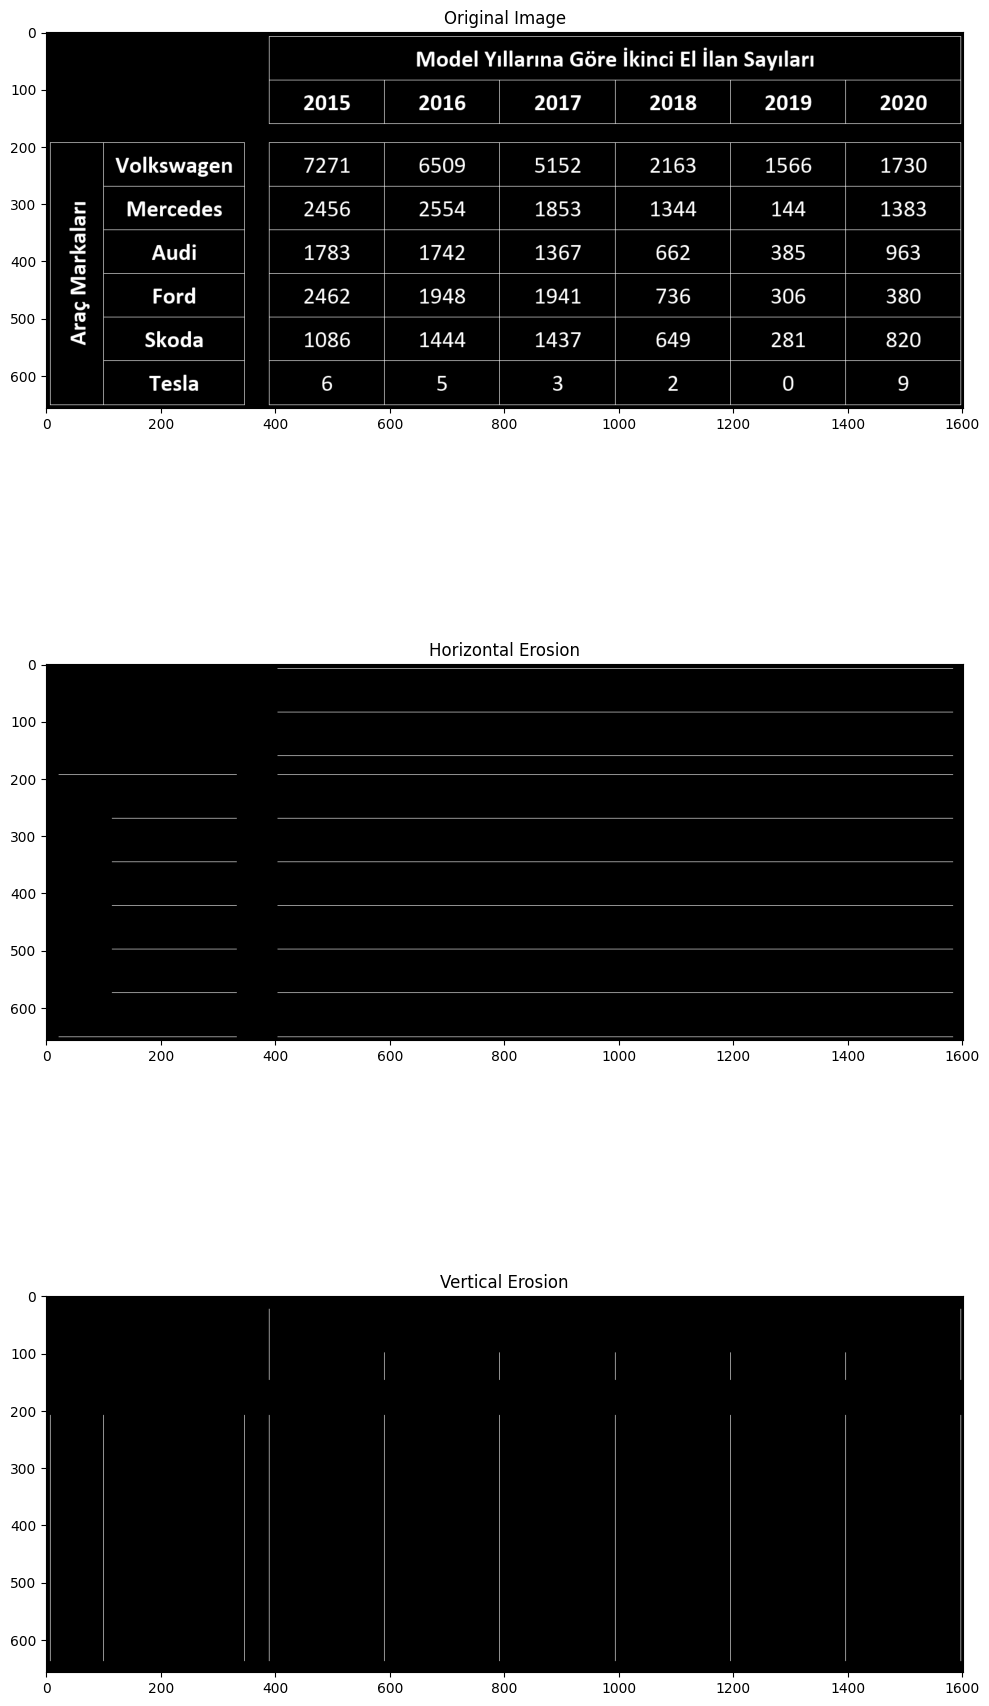

In [19]:
tabloResim = cv2.imread('DATA/16_table.png',0)
tabloResim = cv2.bitwise_not(tabloResim)

yatayKernel = np.ones(shape=(1,30))
yatayErosion = cv2.erode(tabloResim,yatayKernel,iterations=1)

dikeyKernel = np.ones(shape=(30,1))
dikeyErosion = cv2.erode(tabloResim,dikeyKernel,iterations=1)

fig, axs = plt.subplots(3, 1, figsize=(10, 20))

axs[0].imshow(tabloResim, cmap='gray')
axs[0].set_title('Original Image')

axs[1].imshow(yatayErosion, cmap='gray')
axs[1].set_title('Horizontal Erosion')

axs[2].imshow(dikeyErosion, cmap='gray')
axs[2].set_title('Vertical Erosion')

plt.tight_layout()
plt.show()

In [18]:
kucukResim = cv2.imread('DATA/11_opencv-logo-2.png')
buyukResimOrj = cv2.imread('DATA/1_ayasofya.jpg')
# kucukResim = cv2.cvtColor(kucukResim,cv2.COLOR_BGR2RGB)
# buyukResim = cv2.cvtColor(buyukResim,cv2.COLOR_BGR2RGB)
kucukResimGray = cv2.cvtColor(kucukResim,cv2.COLOR_RGB2GRAY)
ret, maske = cv2.threshold(kucukResimGray, 10, 255, cv2.THRESH_BINARY)
mask_inv = cv2.bitwise_not(maske)
is_start=False

def mouse_callback(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDOWN:
        buyukResim = buyukResimOrj.copy()
        # Ensure the small image fits within the large image at the click location
        if y + kucukResim.shape[0] <= buyukResim.shape[0] and x + kucukResim.shape[1] <= buyukResim.shape[1]:
            roi = buyukResim[y:y + kucukResim.shape[0], x:x + kucukResim.shape[1]]
            roi_bg = cv2.bitwise_and(roi, roi, mask=mask_inv)
            roi_fg = cv2.bitwise_and(kucukResim, kucukResim, mask=maske)
            dst = cv2.add(roi_bg, roi_fg)
            buyukResim[y:y + kucukResim.shape[0], x:x + kucukResim.shape[1]] = dst
            cv2.imshow('Image', buyukResim)

cv2.namedWindow('Image')
cv2.setMouseCallback('Image', mouse_callback)

while True:
    if(is_start==False):
        cv2.imshow('Image', buyukResimOrj)
        is_start=True
    if cv2.waitKey(1) & 0xFF == 27:  # Press 'ESC' to exit
        break

cv2.destroyAllWindows()


In [16]:

## Vize +10

import cv2
import numpy as np

# Resim üzerine tıklanan yerin koordinatlarını kaydeden fonksiyon
def click_event(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDOWN:
        # Tıklanan noktayı merkez alarak 50x50 bir alanın sınırlarını belirle
        x_start = max(0, x - 25)
        y_start = max(0, y - 25)
        x_end = min(img.shape[1], x + 25)
        y_end = min(img.shape[0], y + 25)
        
        # Bölgeyi gri tonlamaya çevir
        roi = img[y_start:y_end, x_start:x_end]
        gray_roi = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
        gray_roi_bgr = cv2.cvtColor(gray_roi, cv2.COLOR_GRAY2BGR)

        # Gri bölgeyi orijinal resme geri ekle
        img[y_start:y_end, x_start:x_end] = gray_roi_bgr

        # Değiştirilmiş resmi göster
        cv2.imshow("Image", img)

# Resmi yükle
img = cv2.imread('DATA/1_ayasofya.jpg')

# Pencereyi aç ve tıklama olaylarını izle
cv2.imshow("Image", img)
cv2.setMouseCallback("Image", click_event)

# Çıkış için 'q' tuşuna basılmasını bekle
while True:
    if cv2.waitKey(1) & 0xFF ==27:
        break

# Pencereyi kapat
cv2.destroyAllWindows()


In [ ]:
import cv2
import numpy as np

# Küçük alanı zoom ile göstermek için bir fonksiyon
def zoom_area(event, x, y, flags, param):
    global img, original_img

    if event == cv2.EVENT_MOUSEMOVE:
        # Tıklanan yerin etrafında 50x50'lik alanı belirle
        x_start = max(0, x - 25)
        y_start = max(0, y - 25)
        x_end = min(img.shape[1], x + 25)
        y_end = min(img.shape[0], y + 25)

        # Küçük alanı kopyala ve zoom yap
        zoomed_area = original_img[y_start:y_end, x_start:x_end]
        zoomed_area = cv2.resize(zoomed_area, (150, 150), interpolation=cv2.INTER_LINEAR)

        # Orijinal resmi kopyala
        img = original_img.copy()

        # Zoom yapılan alanı orijinal resmin bir kısmına yerleştir (örneğin, sol üst köşe)
        img[y_start:y_end, x_start:x_end] = zoomed_area

        # Resmi güncelle ve göster
        cv2.imshow("Image", img)

    elif event == cv2.EVENT_LBUTTONDOWN:
        # Fare sol tık yapıldığında orijinal resmi geri yükle
        img = original_img.copy()
        cv2.imshow("Image", img)

# Resmi yükle
original_img = cv2.imread('DATA/1_ayasofya.jpg')

# Resmin kopyasını oluştur (üzerinde işlem yapmak için)
img = original_img.copy()

# Pencereyi aç ve mouse hareketlerini izle
cv2.imshow("Image", img)
cv2.setMouseCallback("Image", zoom_area)

# Çıkış için 'q' tuşuna basılmasını bekle
while True:
    if cv2.waitKey(1) & 0xFF == 27:
        break

# Pencereyi kapat
cv2.destroyAllWindows()


In [30]:
r1 = cv2.imread('DATA/dummy1.png')
r2 = cv2.imread('DATA/dummy2.png')
startpoint = (0,0)
endpoint = (0,0)

is_click=False

def mouse_callback(event, x, y, flags, param):
    global startpoint, endpoint, is_click, r1, r2
    if event == cv2.EVENT_LBUTTONDOWN:
        startpoint = (x, y) 
        
    elif event == cv2.EVENT_LBUTTONUP:
        endpoint = (x, y)
        x1, y1 = min(startpoint[0], endpoint[0]), min(startpoint[1], endpoint[1])
        x2, y2 = max(startpoint[0], endpoint[0]), max(startpoint[1], endpoint[1])
        r1[y1:y2, x1:x2] = r2[y1:y2, x1:x2]

cv2.namedWindow('Image')
cv2.namedWindow('Drawing')
cv2.setMouseCallback('Drawing', mouse_callback)

while True:
    cv2.imshow('Image', r1)
    cv2.imshow('Drawing', r2)
    if cv2.waitKey(1) & 0xFF == 27:  # Press 'ESC' to exit
        break

cv2.destroyAllWindows()
